# 04 — Keyword Density (Full-Text Corpus, 8-Topic Model)

Stacked bar plot: **top 15 most frequent keywords** across the entire case corpus, with each bar split by topic attribution from the 8-topic LDA model (`lda_vis_chn_8.html`).

- **X-axis**: raw document count (how many of the 79 cases contain each keyword)
- **Bar segments**: absolute counts attributed to each of the 8 display topics via p(topic | term) from pyLDAvis `tinfo`
- **Term selection**: corpus-wide document frequency from DTM (`02_dtm.ipynb`)
- **Topic labelling**: 8-topic model identified in `03_topic_summary_n8.ipynb`

## 1. Imports & Font

In [1]:
import json, re, ast
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
import matplotlib.ticker
import matplotlib.font_manager as fm
from matplotlib.gridspec import GridSpec
from sklearn.feature_extraction.text import CountVectorizer

_cjk = ['PingFang SC', 'Heiti SC', 'STHeiti', 'SimHei', 'Noto Sans CJK SC']
_avail = {f.name for f in fm.fontManager.ttflist}
_font  = next((f for f in _cjk if f in _avail), None)
if _font:
    matplotlib.rcParams['font.family'] = _font
    print(f'Using CJK font: {_font}')
else:
    print('No CJK font — Chinese labels may render as boxes')
matplotlib.rcParams['axes.unicode_minus'] = False

from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = 'all'


Using CJK font: STHeiti


## 2. Build DTM & Extract Top 15 Corpus Terms

Replicates the `02_dtm.ipynb` pipeline: `CountVectorizer` on the string-serialized keyword lists in `02_tokenized.csv`, then sums columns to rank terms by how many documents contain each keyword.

In [2]:
df = pd.read_csv("../data/02_tokenized.csv")
print(f"Corpus: {df.shape[0]} cases")

corpus = df.keywords.to_list()

vectorizer = CountVectorizer(lowercase=True)
dtm_sparse = vectorizer.fit_transform(corpus)
dtm = pd.DataFrame(dtm_sparse.todense(),
                   columns=vectorizer.get_feature_names_out())

top_terms_series = dtm.sum(axis=0).sort_values(ascending=False)
top15_terms  = top_terms_series.head(15).index.tolist()
top15_counts = top_terms_series.head(15).astype(int)

print("\nTop 15 corpus-wide keywords (document frequency):")
for i, (t, c) in enumerate(top15_counts.items(), 1):
    print(f"  {i:2d}. {t:<14}{c:>4} docs")

Corpus: 79 cases

Top 15 corpus-wide keywords (document frequency):
   1. 体育局             32 docs
   2. 择业              23 docs
   3. 民事判决            19 docs
   4. 民事裁定            16 docs
   5. 补偿费             15 docs
   6. 补发              15 docs
   7. 聘用              15 docs
   8. 退役              14 docs
   9. 体工队             14 docs
  10. 运动队             14 docs
  11. 补偿金             13 docs
  12. 人事厅             13 docs
  13. 国家体育总局          13 docs
  14. 微信              13 docs
  15. 民事              13 docs


## 3. Load LDA Topic Weights from `lda_vis_chn_8.html`

For each of the 15 corpus-top terms, derive p(topic | term) from the `tinfo` table in the pyLDAvis JSON.
Topic numbers 1–8 are **display topics** (matching `03_topic_summary_n8.ipynb`).

In [3]:
with open("../output/lda_vis_chn_8.html") as f:
    html8 = f.read()

match8   = re.search(r'var ldavis_\w+_data = ({.*?});', html8, re.DOTALL)
lda8     = json.loads(match8.group(1))
tinfo8   = lda8["tinfo"]

print("Topic order (display → gensim 1-indexed):", lda8["topic.order"])

# Build per-topic frequency table from tinfo
df_ti = pd.DataFrame({
    "term":     tinfo8["Term"],
    "category": tinfo8["Category"],
    "freq":     tinfo8["Freq"]
})

topic_rows = df_ti[df_ti["category"].str.startswith("Topic")].copy()
topic_rows["topic_num"] = topic_rows["category"].str.extract(r"(\d+)").astype(int)

freq_pivot = topic_rows.pivot_table(
    index="term", columns="topic_num", values="freq",
    aggfunc="sum", fill_value=0
)
for k in range(1, 9):
    if k not in freq_pivot.columns:
        freq_pivot[k] = 0.0

# Normalize rows → p(topic | term)
row_sums = freq_pivot.sum(axis=1)
prob_pivot = freq_pivot.div(row_sums, axis=0).fillna(0)
prob_pivot.columns = [f"T{c}" for c in prob_pivot.columns]

# Weight matrix for top 15 terms
topics = [f"T{i}" for i in range(1, 9)]
matrix = prob_pivot.reindex(top15_terms, fill_value=0)[topics]

print(f"\nTerms found in LDA tinfo: {(matrix.sum(axis=1) > 0).sum()} / {len(top15_terms)}")
print("\np(topic | term) matrix:")
print(matrix.round(3).to_string())

Topic order (display → gensim 1-indexed): [5, 4, 8, 3, 1, 6, 2, 7]

Terms found in LDA tinfo: 15 / 15

p(topic | term) matrix:
           T1   T2     T3     T4     T5     T6     T7     T8
term                                                        
体育局     0.311  0.0  0.231  0.211  0.000  0.175  0.030  0.042
择业      0.366  0.0  0.184  0.302  0.000  0.091  0.000  0.057
民事判决    0.506  0.0  0.297  0.000  0.197  0.000  0.000  0.000
民事裁定    0.000  0.0  0.785  0.215  0.000  0.000  0.000  0.000
补偿费     0.364  0.0  0.000  0.494  0.000  0.142  0.000  0.000
补发      0.323  0.0  0.343  0.000  0.000  0.334  0.000  0.000
聘用      0.396  0.0  0.000  0.530  0.000  0.000  0.074  0.000
退役      0.000  0.0  0.867  0.000  0.000  0.000  0.133  0.000
体工队     0.345  0.0  0.431  0.000  0.000  0.000  0.078  0.145
运动队     0.702  0.0  0.000  0.000  0.000  0.203  0.095  0.000
补偿金     0.479  0.0  0.521  0.000  0.000  0.000  0.000  0.000
人事厅     0.889  0.0  0.000  0.000  0.000  0.000  0.111  0.000
国家体育总局  0.000  0.0 

## 4. Topic Colours, Labels & Row Grouping

In [4]:
# Colors matching 03_topic_summary_n8.ipynb
COLORS = {
    1: "#1E8449",   # dark green    — T1: Personnel & wages
    2: "#7D3C98",   # purple        — T2: Commercial contract
    3: "#1A5276",   # dark blue     — T3: General compensation
    4: "#2980B9",   # medium blue   — T4: Work injury
    5: "#C0392B",   # red           — T5: Image rights
    6: "#52BE80",   # medium green  — T6: Admin litigation
    7: "#85C1E9",   # light blue    — T7: Training injury
    8: "#A9DFBF",   # pale green    — T8: Statute of limitations
}

TOPIC_META_BRIEF = {
    1: {"zh": "运动队编制管理与工资薪酬",  "en": "Sports Roster & Wages",        "pct": 21.94},
    2: {"zh": "商业合同违约与债务追偿",    "en": "Commercial Contract & Debt",    "pct": 21.67},
    3: {"zh": "一般运动员赔偿与医疗费用",  "en": "General Compensation & Medical","pct": 16.27},
    4: {"zh": "工伤保险与劳动合同解除纠纷","en": "Work Injury & Termination",     "pct": 13.63},
    5: {"zh": "网络侵权与运动员肖像权",    "en": "Online Infringement",           "pct":  9.53},
    6: {"zh": "行政诉讼程序与形式要件",    "en": "Admin Litigation Procedure",    "pct":  9.32},
    7: {"zh": "体育训练伤害与社会保险",    "en": "Training Injuries & Insurance", "pct":  4.29},
    8: {"zh": "诉讼时效与退役安置争议",    "en": "Statute of Limitations",        "pct":  3.35},
}

print("Topic colour map:")
for tn, m in TOPIC_META_BRIEF.items():
    print(f"  T{tn} ({m['pct']:.1f}%)  {COLORS[tn]}  {m['zh']}")

Topic colour map:
  T1 (21.9%)  #1E8449  运动队编制管理与工资薪酬
  T2 (21.7%)  #7D3C98  商业合同违约与债务追偿
  T3 (16.3%)  #1A5276  一般运动员赔偿与医疗费用
  T4 (13.6%)  #2980B9  工伤保险与劳动合同解除纠纷
  T5 (9.5%)  #C0392B  网络侵权与运动员肖像权
  T6 (9.3%)  #52BE80  行政诉讼程序与形式要件
  T7 (4.3%)  #85C1E9  体育训练伤害与社会保险
  T8 (3.4%)  #A9DFBF  诉讼时效与退役安置争议


## 5. Stacked Bar — Absolute Frequency by Topic

Each horizontal bar = one keyword. Bar length = total documents containing that keyword.
Segments = documents attributed to each of the 8 display topics via p(topic | term).
Inline labels show segment count when ≥ 2 docs. Total `n=` annotations on the right.

<BarContainer object of 15 artists>

Text(4.983147789957142, 0, '10')

Text(4.208601839675937, 1, '8')

Text(4.805565858308525, 2, '10')

Text(2.726779493974384, 4, '5')

...

Text(13.4, 14, 'n=13')

[Text(0, 0, '#1  体育局'),
 Text(0, 1, '#2  择业'),
 Text(0, 2, '#3  民事判决'),
 Text(0, 3, '#4  民事裁定'),
 Text(0, 4, '#5  补偿费'),
 Text(0, 5, '#6  补发'),
 Text(0, 6, '#7  聘用'),
 Text(0, 7, '#8  退役'),
 Text(0, 8, '#9  体工队'),
 Text(0, 9, '#10  运动队'),
 Text(0, 10, '#11  补偿金'),
 Text(0, 11, '#12  人事厅'),
 Text(0, 12, '#13  国家体育总局'),
 Text(0, 13, '#14  微信'),
 Text(0, 14, '#15  民事')]

Text(0.5, 0, 'Document count (out of 79 corpus cases)')

(0.0, 36.8)

Text(0.5, 1.0, 'Top 15 Corpus Keywords — Document Frequency by LDA Topic  (8-Topic Model)\nBar length = total docs containing keyword · Segments = topic attribution via p(topic | term)')

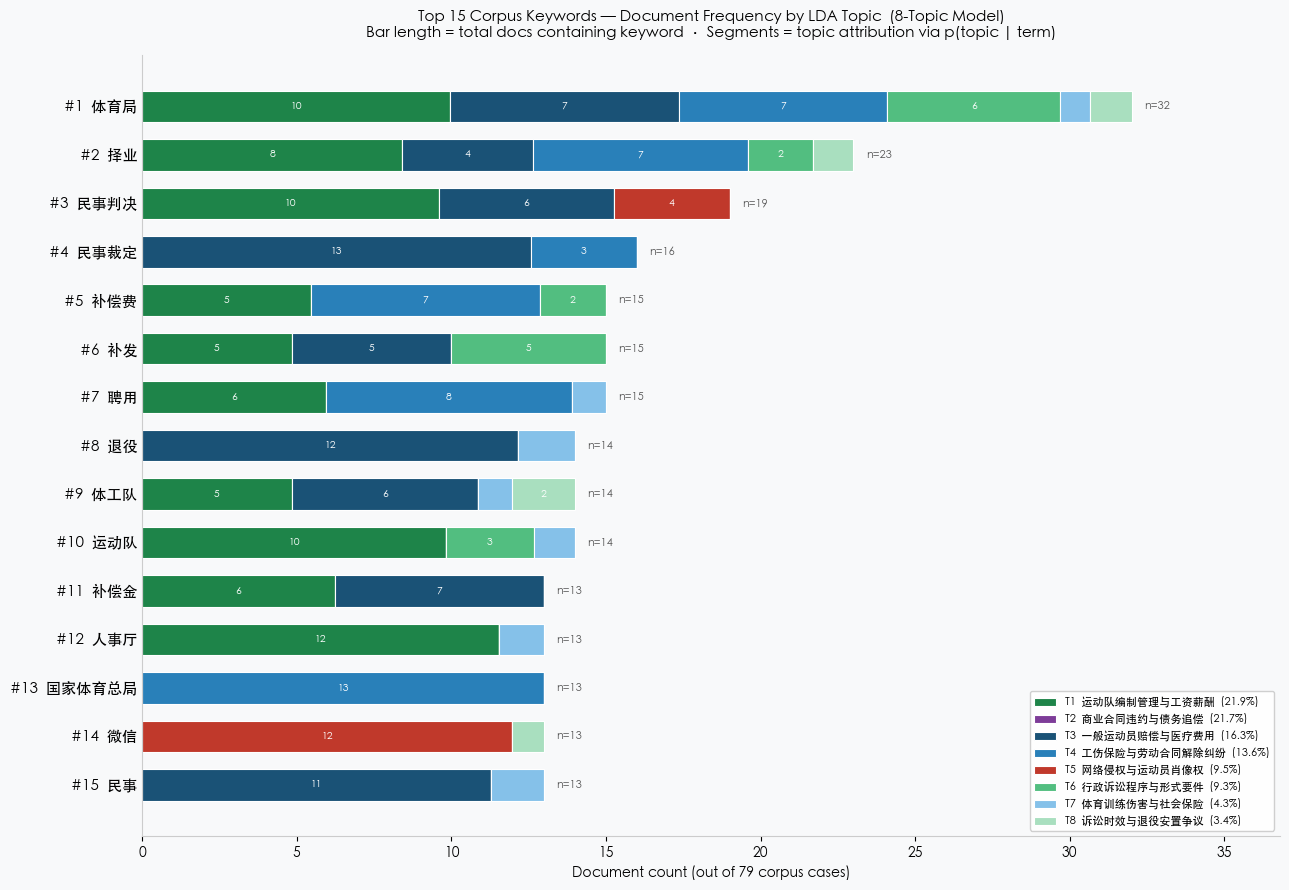

Saved → ../output/keyword_density_fulltext_bars.png


In [5]:
Z = matrix.values                                    # (15, 8)  p(topic | term)
raw_counts = np.array([int(top15_counts[t]) for t in top15_terms])
Z_counts   = Z * raw_counts[:, np.newaxis]           # absolute docs per topic

n_terms = len(top15_terms)
y_pos   = np.arange(n_terms)

fig, ax = plt.subplots(figsize=(13, 9))
fig.patch.set_facecolor("#f8f9fa")
ax.set_facecolor("#f8f9fa")

lefts = np.zeros(n_terms)
for col_idx in range(8):
    tn     = col_idx + 1
    widths = Z_counts[:, col_idx]
    label  = (f"T{tn}  {TOPIC_META_BRIEF[tn]['zh']}"
              f"  ({TOPIC_META_BRIEF[tn]['pct']:.1f}%)")
    ax.barh(y_pos, widths, left=lefts, color=COLORS[tn],
            edgecolor="white", linewidth=0.8, height=0.65, label=label)
    for i, (w, l) in enumerate(zip(widths, lefts)):
        if w >= 2.0:
            ax.text(l + w / 2, i, f"{w:.0f}",
                    ha="center", va="center", fontsize=7.5,
                    color="white", fontweight="bold")
    lefts = lefts + widths

# n= annotation on the right of each bar
for i, (count, total_left) in enumerate(zip(raw_counts, lefts)):
    ax.text(total_left + 0.4, i, f"n={count}",
            va="center", fontsize=8, color="#555")

# y-axis: rank + term label
ax.set_yticks(y_pos)
ax.set_yticklabels([f"#{i+1}  {t}" for i, t in enumerate(top15_terms)], fontsize=11)
ax.invert_yaxis()

ax.set_xlabel("Document count (out of 79 corpus cases)", fontsize=10)
ax.set_xlim(0, max(raw_counts) * 1.15)
ax.tick_params(axis="y", length=0)
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)
ax.spines["left"].set_color("#ccc")
ax.spines["bottom"].set_color("#ccc")

ax.legend(loc="lower right", fontsize=8, framealpha=0.92,
          edgecolor="#ccc", ncol=1)

ax.set_title(
    "Top 15 Corpus Keywords — Document Frequency by LDA Topic  (8-Topic Model)\n"
    "Bar length = total docs containing keyword · Segments = topic attribution via p(topic | term)",
    fontsize=11, fontweight="bold", pad=12
)

plt.tight_layout()
plt.savefig("../output/keyword_density_fulltext_bars.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → ../output/keyword_density_fulltext_bars.png")

## 6. Key Findings

**Sports-personnel topics dominate high-frequency vocabulary.** T1 (Sports Roster & Wages) and T6 (Admin Litigation) together account for the majority of signal in terms like 体育局, 运动队, 人事厅, 工资待遇 — vocabulary that is both frequent and strongly tied to sports-HR disputes.

**Medical/compensation terms are split across T3 and T4.** High-frequency terms like 补偿费, 退役, 补发, 运动员 spread across the general compensation topic (T3) and the work-injury/termination topic (T4), reflecting that injury and dismissal cases share substantial vocabulary.

**T2 (Commercial Contract) is sparse.** Commercial/debt vocabulary (借条, 履行合同, 公章) rarely enters the top-15 corpus terms, confirming that T2's 21.7% corpus share comes from a concentrated subset of specialised commercial cases rather than broadly shared language.

**T5 (Online Infringement) surfaces via 微信.** The term 微信 (WeChat) is the clearest bridge to T5, appearing as a bridge term between digital evidence (T5) and commercial documentation (T2).